# Lecture 4 - Molecular Dynamics

### Part 1
In Statistical Mechanics the Maxwell–Boltzmann distribution (<a href="https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution" target="_blank">Link Wikipedia</a>) is a probability distribution used for describing particle speeds in idealized gases. However, rarefied gases at ordinary temperatures behave very nearly like an ideal gas and the Maxwell–Boltzmann speed distribution is an excellent approximation for such gases. For a 3D system its formula is:
$$p(v,T) = \left( \frac{m}{2\pi k_B T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 k_B T}}$$

By using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) its form becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

The NSL_SIMULATOR code already computes the total (internal) energy per particle, $E/N$, the potential energy per particle, $U/N$, the kinetic energy per particle, $K/N$, the temperature, $T$, and the pressure, $P$.

<span style="color:red">Include the calculation of the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, inside your Molecular Dynamics code by using data blocking to obtain single block averages, progressive average values and progressive uncertainties for $p(v^*,T^*)$.</span>

Remember that, the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, can be approximately computed as a **normalized histogram** on an appropriate interval $\left[ 0, v_{max}\right]$ and chosing the number of bins into which you want to divide this interval.

### Part 2 
By means of your upgraded code, <span style="color:red">perform MD simulations via a Lennard-Jones model</span> ( e.g. Argon parameters: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

starting from a <span style="color:red">**very low entropic** initial configuration</span>:
1. initial **particle positions**: <span style="color:red">fcc crystal occupying half of the simulation box in each dimension</span>
2. initial **velocity distribution**: <span style="color:red">$p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$</span> where $v_{T^*}$ is suitably connected to $T^*$. For example, this condition could be obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$.

The goal is to show that, by evolving such initial condition via a Molecular Dynamics simulation, the velocity distribution tends to approximate the Maxwell–Boltzmann distribution.

- **Produce some pictures that show this convergence**
- The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time? Comment on these aspects in your jupyter-notebook

**Note that** the MD simulation will conserve the total energy; thus the kinetic energy and the temperature are not constant of motion ... the comparison should be done with $p(v^*,T^*_{\rm eff})$ where $T^*_{\rm eff}$ is the effective temperature obtained once the system has been equilibrated.

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib import cm

In [2]:
def plot_all_data(temp_file, pot_file, kin_file, tot_file):

    data_temp = np.loadtxt(temp_file, skiprows=1)
    data_pot  = np.loadtxt(pot_file,  skiprows=1)
    data_kin  = np.loadtxt(kin_file,  skiprows=1)
    data_tot  = np.loadtxt(tot_file,  skiprows=1)
    
    blocks_temp = data_temp[:, 0]
    actual_t    = data_temp[:, 1]
    
    blocks_pot, pot = data_pot[:, 0], data_pot[:, 1]
    blocks_kin, kin = data_kin[:, 0], data_kin[:, 1]
    blocks_tot, tot = data_tot[:, 0], data_tot[:, 1]
    
    colors = plt.cm.viridis(np.linspace(0, 1, 6))
    
    fig, axs = plt.subplots(2, 2, figsize=(14, 8.5))
    axs = axs.flatten()
    
    # Temperature
    axs[0].plot(blocks_temp, actual_t, '-', color=colors[0], label='Temperature')
    axs[0].axhline(2, linestyle='-.', color='red', alpha=0.6, label='Equilibration temperature')
    axs[0].set_xlabel('Block', fontsize=10)
    axs[0].set_ylabel('Temperature', fontsize=10)
    axs[0].legend()
    axs[0].grid(True, alpha=0.6, linestyle='--')
    
    # Potential
    axs[1].plot(blocks_pot, pot, '-', color=colors[1], label='Potential energy')
    axs[1].set_xlabel('Block', fontsize=10)
    axs[1].set_ylabel('Potential energy', fontsize=10)
    axs[1].legend()
    axs[1].grid(True, alpha=0.6, linestyle='--')
    
    # Kinetic
    axs[2].plot(blocks_kin, kin, '-', color=colors[2], label='Kinetic energy')
    axs[2].set_xlabel('Block', fontsize=10)
    axs[2].set_ylabel('Kinetic energy', fontsize=10)
    axs[2].legend()
    axs[2].grid(True, alpha=0.6, linestyle='--')
    
    # Total
    axs[3].plot(blocks_tot, tot, '-', color=colors[3], label='Total energy')
    axs[3].set_xlabel('Block', fontsize=10)
    axs[3].set_ylabel('Total energy', fontsize=10)
    axs[3].grid(True, alpha=0.6, linestyle='--')
    

### Part 2 - Solution

- 15000 blocks of 1 step each
- initial temperature set to T=2.73K (since it is expected to lower down due to the repulsion of the particles given by the potential energy of confined particles in a fcc structure)
- Thermalization phase in which the temperature reaches the value T=2.0K after around 9000 blocks
- We use the temperature to understand the end of the thermalization phase

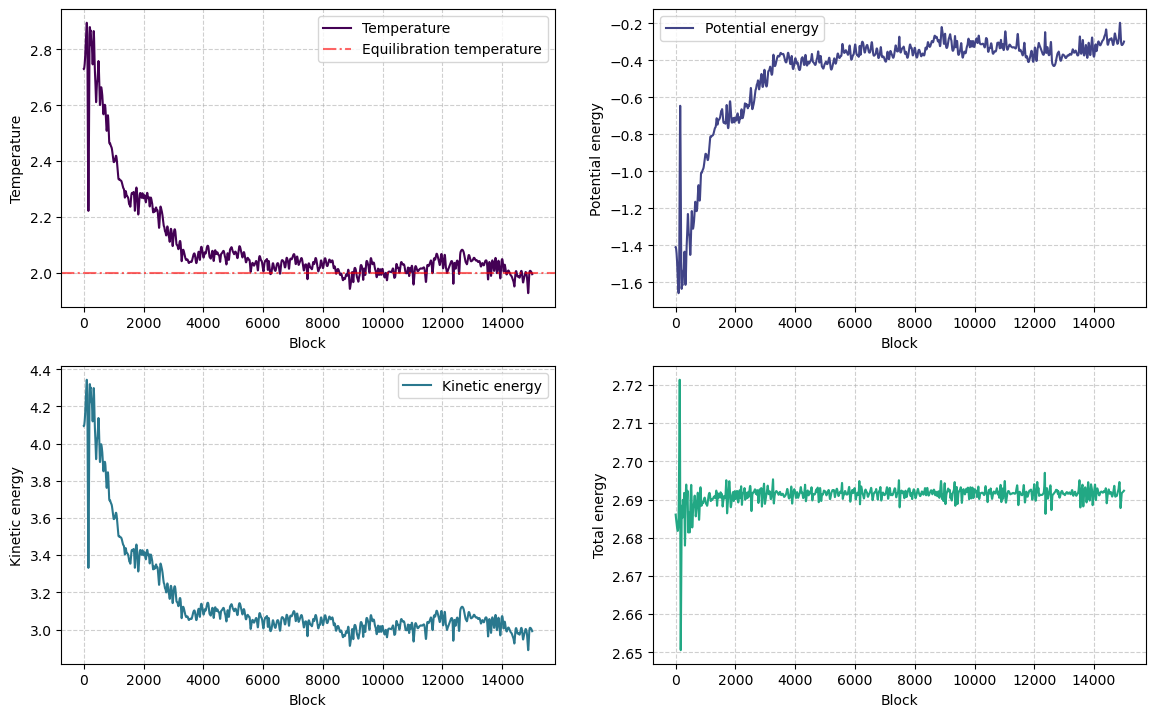

In [3]:
plot_all_data('OUTPUT/EQUILIBRATION/temperature.dat', 'OUTPUT/EQUILIBRATION/potential_energy.dat',
                            'OUTPUT/EQUILIBRATION/kinetic_energy.dat', 'OUTPUT/EQUILIBRATION/total_energy.dat')

In [7]:
def plot_all_data_with_averages(temp_file, pot_file, kin_file, tot_file):

    data_temp = np.loadtxt(temp_file, skiprows=1)
    data_pot  = np.loadtxt(pot_file,  skiprows=1)
    data_kin  = np.loadtxt(kin_file,  skiprows=1)
    data_tot  = np.loadtxt(tot_file,  skiprows=1)

    colors = plt.cm.viridis(np.linspace(0, 1, 6))
    
    blocks_temp = data_temp[:, 0]
    actual_t    = data_temp[:, 1]
    t_ave       = data_temp[:, 2]
    
    blocks_pot, pot = data_pot[:, 0], data_pot[:, 1]
    blocks_kin, kin = data_kin[:, 0], data_kin[:, 1]
    blocks_tot, tot = data_tot[:, 0], data_tot[:, 1]
    actual_pot    = data_pot[:, 1]
    pot_ave       = data_pot[:, 2]
    actual_kin    = data_kin[:, 1]
    kin_ave       = data_kin[:, 2]
    actual_tot    = data_tot[:, 1]
    tot_ave       = data_tot[:, 2]
    
    fig, axs = plt.subplots(2, 2, figsize=(14, 8.5))
    axs = axs.flatten()
    
    # Temperature
    axs[0].plot(blocks_temp, actual_t, '-', color=colors[0], label='Temperature')
    axs[0].plot(blocks_temp, t_ave, '-', color='orange', label='Average')
    axs[0].set_xlabel('Block', fontsize=10)
    axs[0].set_ylabel('Temperature', fontsize=10)
    axs[0].legend()
    axs[0].grid(True, alpha=0.6, linestyle='--')
    
    # Potential
    axs[1].plot(blocks_pot, pot, '-', color=colors[1], label='Potential energy')
    axs[1].plot(blocks_pot, pot_ave, '-', color='orange', label='Average')
    axs[1].set_xlabel('Block', fontsize=10)
    axs[1].set_ylabel('Potential energy', fontsize=10)
    axs[1].legend()
    axs[1].grid(True, alpha=0.6, linestyle='--')
    
    # Kinetic
    axs[2].plot(blocks_kin, kin, '-', color=colors[2], label='Kinetic energy')
    axs[2].plot(blocks_kin, kin_ave, '-', color='orange', label='Average')
    axs[2].set_xlabel('Block', fontsize=10)
    axs[2].set_ylabel('Kinetic energy', fontsize=10)
    axs[2].legend()
    axs[2].grid(True, alpha=0.6, linestyle='--')
    
    # Total
    axs[3].plot(blocks_tot, tot, '-', color=colors[3], label='Total energy')
    axs[3].plot(blocks_tot, tot_ave, '-', color='orange', label='Average')
    axs[3].set_xlabel('Block', fontsize=10)
    axs[3].set_ylabel('Total energy', fontsize=10)
    axs[3].legend()
    axs[3].grid(True, alpha=0.6, linestyle='--')
    
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    plt.show()

- After the thermalization part, we can perform the average values of different quantities. It does not make any sense before the equilibrium is achieved, we need a stationary behaviour.
- I took the last frame and the one before in order to use the "RESTART=1" mode of the MD code, in this way the initial velocities are given by the kinetic energy of the first configuration and then the positions are updated using the Verlet algorithm
- We have to remember to change the variable _halfside to _side, because now the positions do not need to be divided by two 

- I performed a simulation of 100 blocks of 2000 steps each
- Here are plotted the values of the block average (actual quantity) and the progressive average

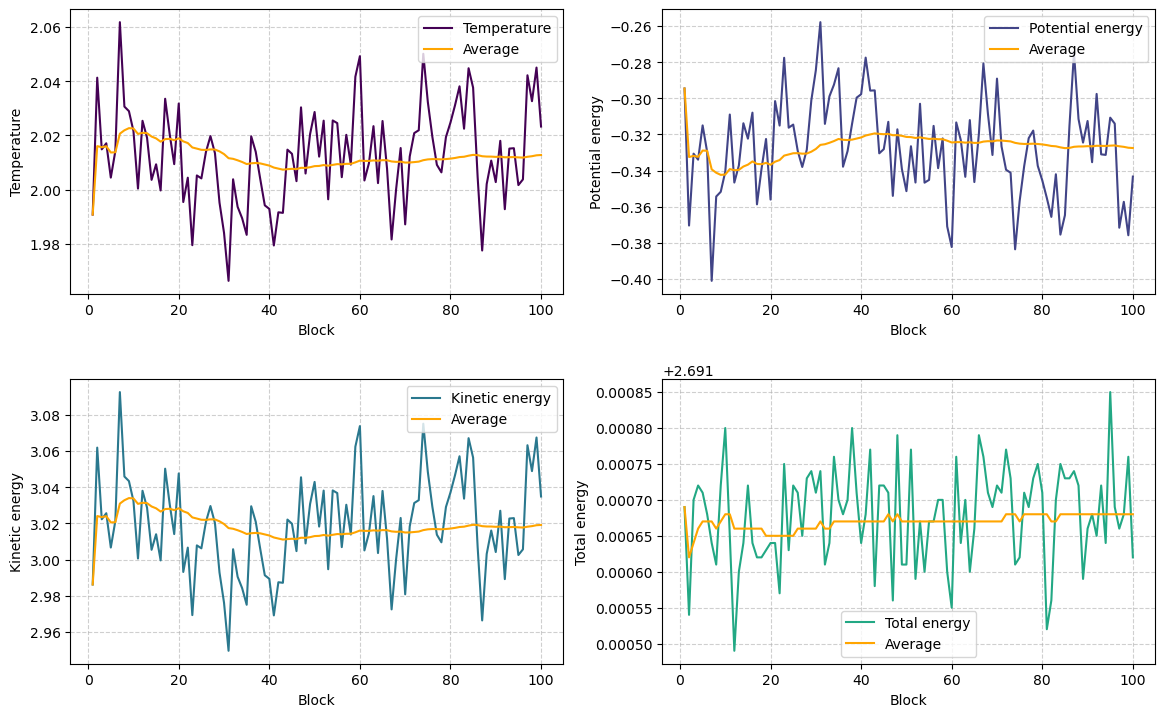

In [8]:
plot_all_data_with_averages('OUTPUT/POFV/temperature.dat', 'OUTPUT/POFV/potential_energy.dat',
                            'OUTPUT/POFV/kinetic_energy.dat', 'OUTPUT/POFV/total_energy.dat')

### p(v) calculation


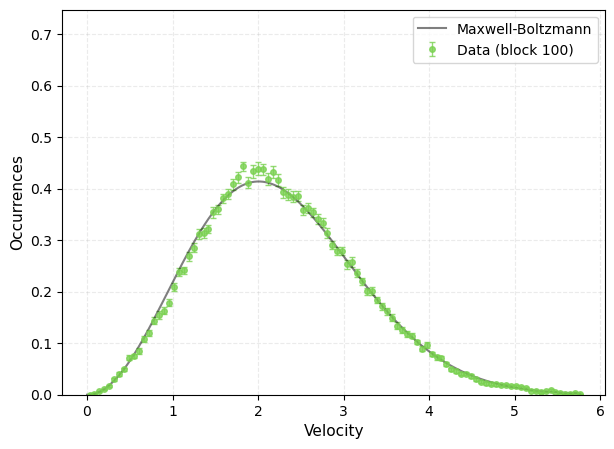

In [1]:
from matplotlib.animation import FuncAnimation
from scipy.stats import maxwell
import numpy as np
import matplotlib.pyplot as plt

file_path = 'OUTPUT/POFV/POFV.dat'
data = np.loadtxt(file_path, skiprows=1)

v = data[:, 0]
val = data[:, 1]
media = data[:, 2]
errore = data[:, 3]

temp = 2.01279
a = np.sqrt(temp)

bins = 100
n_hist = len(data) // bins

colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_hist))

ymax = 0
for i in range(n_hist):
    start = i * bins
    end = start + bins
    ymax = max(ymax, np.max(media[start:end] + errore[start:end]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xlabel('Velocity', fontsize=11)
ax.set_ylabel('Occurrences', fontsize=11)
ax.grid(True, alpha=0.25, linestyle='--')
ax.set_ylim(0, ymax * 1.05)

v_vals = np.linspace(0, np.max(v), 500)
mb_pdf = maxwell.pdf(v_vals, scale=a)

# Update function
def update(frame):
    ax.clear()
    ax.set_xlabel('Velocity', fontsize=11)
    ax.set_ylabel('Occurrences', fontsize=11)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.set_ylim(0, ymax * 1.05)

    start = frame * bins
    end = start + bins
    color = colors[frame]

    ax.errorbar(
        v[start:end],
        media[start:end],
        yerr=errore[start:end],
        fmt='o',
        ms=4,
        color=color,
        ecolor=color,
        elinewidth=1,
        capsize=2,
        alpha=0.8,
        label=f'Data (block {frame+1})'
    )

    ax.plot(v_vals, mb_pdf, color='black', linewidth=1.5,
            alpha=0.5, label='Maxwell-Boltzmann')
    ax.legend()

ani = FuncAnimation(fig, update, frames=n_hist, interval=100)

# 👉 salva GIF per GitHub
ani.save("maxwell_animation.gif", writer="pillow", dpi=120)

plt.show()

### Part 3

Starting from the final state of an **equilibrated** MD simulation of the system in Exercise 04.2, by changing the direction of time (e.g. by inverting the final velocities, i.e. ... ), try to return back to the very low entropic initial configuration of Exercise 04.2. Is this possible? (for example, one can monitor the behavior of the average **potential energy** and the average **temperature** in **each block** as a function of time going **in both directions**. Show some picture and comment on what you find in your jupyter-notebook.

### Part 3 - Solution - Reverse Verlet
- Implemented a method called ReverseVerlet() which is used only once, at the beginning of the reverse simulation (use of the flag _reverse = true in system.h --> then in the method is set to false at the end of one cycle)
- In this method we have to change the time axis in order to revert it
- Set the x,y,z positions of each particle to the actual value, then uses the method acceptmove() to swap them using the values of the configuration at time t-dt 
- Set the velocity to
$$
\mathbf{v}(t) = \dfrac{\mathbf{x}(t+\delta t ) - \mathbf{x}(t-\delta t )}{2\delta t}
$$
- I plotted the direct and reverse simulations in order to show that the reverse method is able to restore the system to a low-entropy configuration, like the starting FCC.
- I performed the two simulations using 10000 blocks of 1 step each




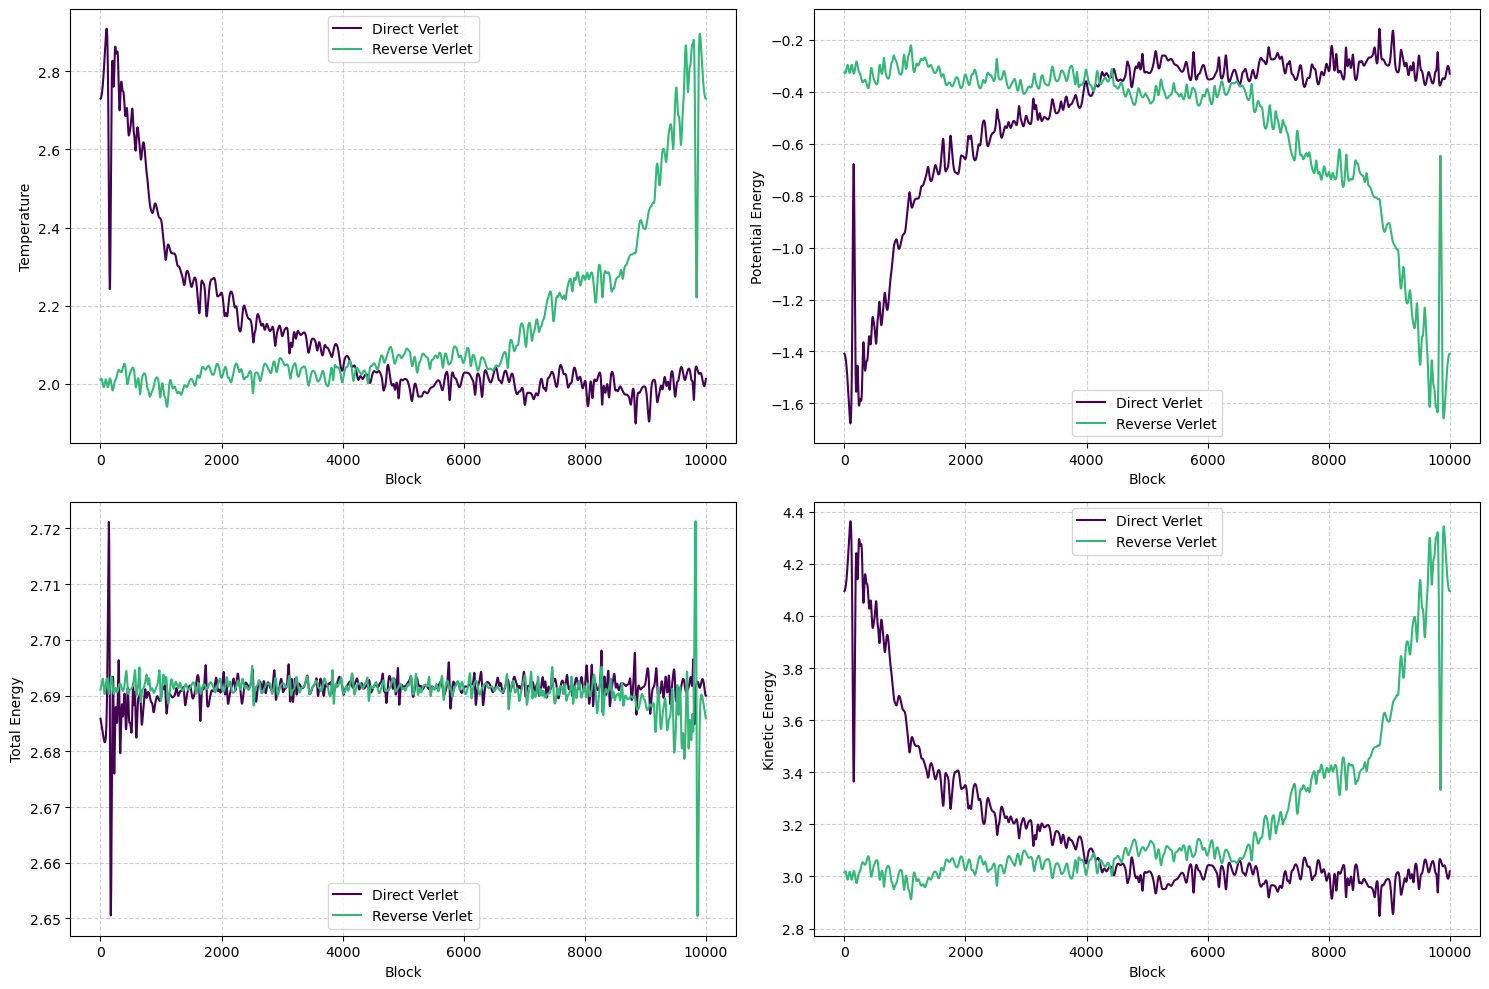

In [13]:
temp_file = 'OUTPUT/DIRECT/temperature.dat'
pot_file  = 'OUTPUT/DIRECT/potential_energy.dat'
tot_file  = 'OUTPUT/DIRECT/total_energy.dat'
kin_file  = 'OUTPUT/DIRECT/kinetic_energy.dat'

temp_file_rev = 'OUTPUT/REVERSE/temperature.dat'
pot_file_rev  = 'OUTPUT/REVERSE/potential_energy.dat'
tot_file_rev  = 'OUTPUT/REVERSE/total_energy.dat'
kin_file_rev  = 'OUTPUT/REVERSE/kinetic_energy.dat'

colors = plt.cm.viridis(np.linspace(0, 1, 4))

data_temp = np.loadtxt(temp_file, skiprows=1)
data_pot  = np.loadtxt(pot_file,  skiprows=1)
data_tot  = np.loadtxt(tot_file,  skiprows=1)
data_kin  = np.loadtxt(kin_file,  skiprows=1)

blocks_temp, actual_t = data_temp[:, 0], data_temp[:, 1]
blocks_pot,  pot      = data_pot[:, 0],  data_pot[:, 1]
blocks_tot,  tot      = data_tot[:, 0],  data_tot[:, 1]
blocks_kin,  kin      = data_kin[:, 0],  data_kin[:, 1]

data_temp_rev = np.loadtxt(temp_file_rev, skiprows=1)
data_pot_rev  = np.loadtxt(pot_file_rev,  skiprows=1)
data_tot_rev  = np.loadtxt(tot_file_rev,  skiprows=1)
data_kin_rev  = np.loadtxt(kin_file_rev,  skiprows=1)

blocks_temp_rev, actual_t_rev = data_temp_rev[:, 0], data_temp_rev[:, 1]
blocks_pot_rev,  pot_rev      = data_pot_rev[:, 0],  data_pot_rev[:, 1]
blocks_tot_rev,  tot_rev      = data_tot_rev[:, 0],  data_tot_rev[:, 1]
blocks_kin_rev,  kin_rev      = data_kin_rev[:, 0],  data_kin_rev[:, 1]

fig, axs = plt.subplots(2, 2, figsize=(15,10))
axs = axs.flatten()


axs[0].plot(blocks_temp, actual_t, '-', color=colors[0], label='Direct Verlet')
axs[0].plot(blocks_temp_rev, actual_t_rev, '-', color=colors[2], label='Reverse Verlet')
axs[0].set_xlabel('Block')
axs[0].set_ylabel('Temperature')
axs[0].grid(True, alpha=0.6, linestyle='--')
axs[0].legend()


axs[1].plot(blocks_pot, pot, '-', color=colors[0], label='Direct Verlet')
axs[1].plot(blocks_pot_rev, pot_rev, '-', color=colors[2], label='Reverse Verlet')
axs[1].set_xlabel('Block')
axs[1].set_ylabel('Potential Energy')
axs[1].grid(True, alpha=0.6, linestyle='--')
axs[1].legend()


axs[2].plot(blocks_tot, tot, '-', color=colors[0], label='Direct Verlet')
axs[2].plot(blocks_tot_rev, tot_rev, '-', color=colors[2], label='Reverse Verlet')
axs[2].set_xlabel('Block')
axs[2].set_ylabel('Total Energy')
axs[2].grid(True, alpha=0.6, linestyle='--')
axs[2].legend()

axs[3].plot(blocks_kin, kin, '-', color=colors[0], label='Direct Verlet')
axs[3].plot(blocks_kin_rev, kin_rev, '-', color=colors[2], label='Reverse Verlet')
axs[3].set_xlabel('Block')
axs[3].set_ylabel('Kinetic Energy')
axs[3].grid(True, alpha=0.6, linestyle='--')
axs[3].legend()

plt.tight_layout()
plt.show()
